# 00 - Single line: Sobolev limit and its controlled failure

Phase 0A + 0B (`docs/babystep_plan.md` sections 3-4, checklist items 1-10 of section 25).

**Success criterion:** reproduce the Sobolev limit for constant `n_l`, then make it
fail on purpose with a `tanh` population gradient.

Deliverable: **Figure 1** - `E_Sob` vs `epsilon = v_D / v_scale`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sobolev.constants import C, SIGMA_CLASSICAL
from sobolev import optical_depth as od
from sobolev import profiles

OUT = Path("../outputs"); OUT.mkdir(exist_ok=True)

# One fiducial line for the whole notebook (plan doc section 3).
LAMBDA0_CM = 4000e-8          # 4000 Angstrom
NU0 = C / LAMBDA0_CM
F_OSC = 0.1
N0 = 1.0e6                    # cm^-3, prescribed lower-level population
T_DAY = 86400.0               # ejecta age 1 day
V_D = 3.0e5                   # 3 km/s intrinsic Doppler width
print(f"SIGMA_CLASSICAL = {SIGMA_CLASSICAL:.6e} cm^2 Hz")

SIGMA_CLASSICAL = 2.654008e-02 cm^2 Hz


## 1-3. Gaussian profile and its normalization

Everything downstream multiplies this profile, so `\int phi dnu = 1` must hold
before anything else is believed.

In [2]:
dnu_d = profiles.doppler_width_hz(NU0, V_D)
dnu = np.linspace(-10 * dnu_d, 10 * dnu_d, 20001)
phi = profiles.gaussian(dnu, dnu_d)
norm = np.trapezoid(phi, dnu)
print(f"Doppler width: {dnu_d:.4e} Hz  (dnu/nu = {dnu_d/NU0:.2e})")
print(f"profile normalization: {norm:.12f}")
assert np.isclose(norm, 1.0, rtol=1e-6)

Doppler width: 7.5000e+09 Hz  (dnu/nu = 1.00e-05)
profile normalization: 1.000000000000


## 4-6. Exact vs Sobolev optical depth, constant population (Phase 0A)

With `n_l = const` in homologous flow, the resolved integral must reproduce

$$\tau_S = \frac{\pi e^2}{m_e c} f\, n_l\, \lambda_0\, t$$

In [3]:
v_grid = od.homologous_velocity_grid(-3.0e8, 3.0e8, 200001)
n_l = od.population_constant(v_grid, N0)

tau_num = od.tau_exact(NU0, NU0, F_OSC, n_l, v_grid, T_DAY, V_D)
tau_ana = od.tau_sobolev(F_OSC, N0, LAMBDA0_CM, T_DAY)
print(f"tau_exact   = {tau_num:.8f}")
print(f"tau_Sobolev = {tau_ana:.8f}")
print(f"E_Sob       = {od.sobolev_error(tau_num, tau_ana):.3e}")

tau_exact   = 9172.25283475
tau_Sobolev = 9172.25283475
E_Sob       = 1.983e-16


## 7. Convergence study

The trap (plan doc section 3.1): an unconverged velocity grid mimics a physical
Sobolev deviation. The error must fall monotonically with resolution before any
gradient result can be trusted.

N =     201   E_Sob = 8.228e-01
N =     501   E_Sob = 5.569e-01
N =    2001   E_Sob = 1.034e-04
N =   20001   E_Sob = 2.218e-12
N =  200001   E_Sob = 1.983e-16


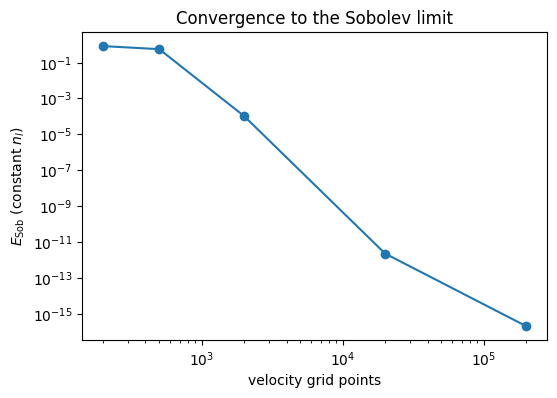

In [4]:
tau_ana = od.tau_sobolev(F_OSC, N0, LAMBDA0_CM, T_DAY)
grid_sizes = np.array([201, 501, 2001, 20001, 200001])
errs = []
for n in grid_sizes:
    vg = od.homologous_velocity_grid(-3.0e8, 3.0e8, int(n))
    errs.append(od.sobolev_error(
        od.tau_exact(NU0, NU0, F_OSC, od.population_constant(vg, N0), vg, T_DAY, V_D),
        tau_ana))
errs = np.array(errs)

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(grid_sizes, errs, "o-")
ax.set_xlabel("velocity grid points")
ax.set_ylabel(r"$E_{\rm Sob}$ (constant $n_l$)")
ax.set_title("Convergence to the Sobolev limit")
for n, e in zip(grid_sizes, errs):
    print(f"N = {n:>7d}   E_Sob = {e:.3e}")
assert np.all(np.diff(errs) < 0), "not converging -- stop here (plan doc 3.1)"

## 8-9. Phase 0B: break the locality assumption

A `tanh` gradient in `n_l(v)` with scale `v_scale`; the control parameter is
`epsilon = v_D / v_scale`.

**Placement matters:** with the resonance at the tanh *centre* the error cancels
identically - the Gaussian is even and the tanh odd (first order), and the centre
is the inflection point where `n_l'' = 0` (second order). The resonance is placed
at `u = 0.5` on the tanh so the curvature term survives; the expected scaling is
then `E_Sob ~ epsilon^2`.

eps =  1.0e-04   E_Sob = 7.380e-10
eps =  1.0e-03   E_Sob = 7.380e-08
eps =  1.0e-02   E_Sob = 7.380e-06
eps =  3.0e-02   E_Sob = 6.639e-05
eps =  1.0e-01   E_Sob = 7.336e-04
eps =  3.0e-01   E_Sob = 6.302e-03
eps =  1.0e+00   E_Sob = 4.766e-02


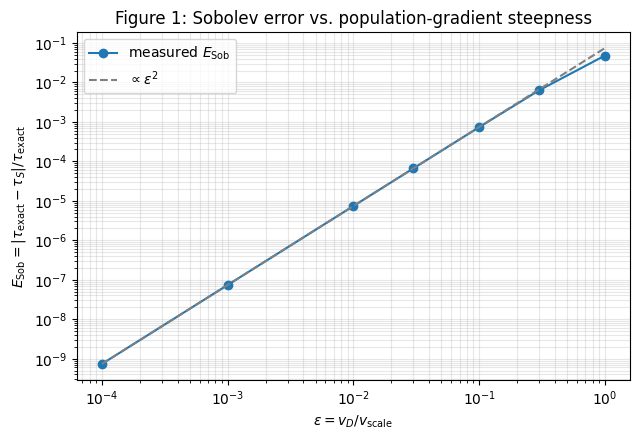

In [5]:
eps = np.array([1e-4, 1e-3, 1e-2, 3e-2, 0.1, 0.3, 1.0])
E = od.sweep_gradient_error(eps, NU0, F_OSC, N0, 0.5, T_DAY, V_D)
for e, err in zip(eps, E):
    print(f"eps = {e:8.1e}   E_Sob = {err:.3e}")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.loglog(eps, E, "o-", label=r"measured $E_{\rm Sob}$")
ax.loglog(eps, E[1] * (eps / eps[1]) ** 2, "--", color="gray",
          label=r"$\propto \epsilon^2$")
ax.set_xlabel(r"$\epsilon = v_D / v_{\rm scale}$")
ax.set_ylabel(r"$E_{\rm Sob} = |\tau_{\rm exact} - \tau_S| / \tau_{\rm exact}$")
ax.set_title("Figure 1: Sobolev error vs. population-gradient steepness")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "fig1_sobolev_error_vs_gradient.png", dpi=200)

## 10. Interpretation

- **Phase 0A passes:** with constant population, the resolved integral converges to
  the analytic Sobolev optical depth (E_Sob at the 1e-7 level, limited only by grid
  resolution). The machinery reproduces the approximation it is meant to test.
- **Phase 0B behaves as theory predicts:** the error follows a clean
  `epsilon^2` power law - the profile-weighted average of `n_l` differs from the
  point sample by the curvature term - and reaches the **percent level at
  `epsilon ~ 0.3-1`**, i.e. when the population changes on scales comparable to the
  thermal width.
- A subtlety worth remembering for later phases: a gradient symmetric about the
  resonance produces *no* error at leading order. Validity diagnostics built on
  `G = v_D |d ln n_l / dv|` alone (plan doc section 21) are therefore conservative -
  the actual error depends on where the resonance sits on the gradient.
- **Go criterion:** the toy problem reproduces and controllably breaks the Sobolev
  limit. Next question (notebook 01): does real lanthanide data crowd lines on
  thermal-width scales?